<a href="https://colab.research.google.com/github/ashwini-kamath2903/email_spam_detection/blob/main/Detecting_Spam_Emails_Using_Tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [95]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [96]:
import warnings
warnings.filterwarnings('ignore')

In [97]:
data = pd.read_csv('email.csv')
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


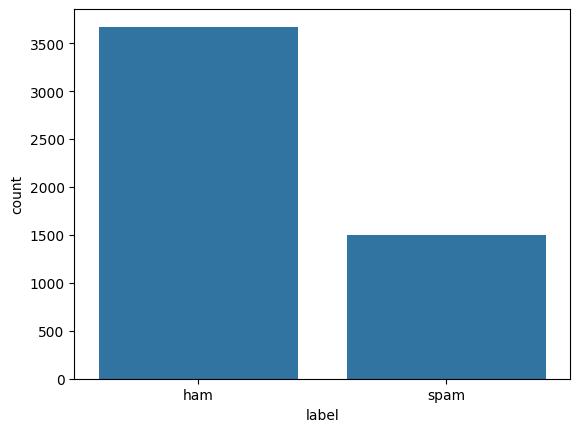

In [98]:
sns.countplot(x='label', data = data)
plt.show()

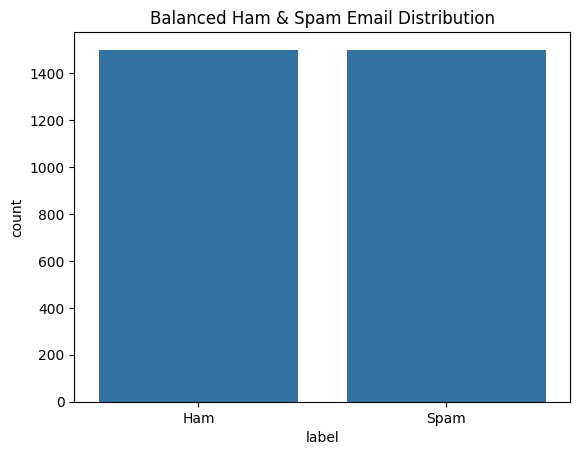

In [99]:
ham_data = data[data['label']=='ham']
spam_data = data[data['label']=='spam']

bal_ham_data = ham_data.sample(n = len(spam_data), random_state = 42)

bal_data = pd.concat([bal_ham_data, spam_data]).reset_index(drop = True)

sns.countplot(x='label', data = bal_data)
plt.title('Balanced Ham & Spam Email Distribution')
plt.xticks(ticks=[0,1], labels = ['Ham', 'Spam'])
plt.show()

In [100]:
bal_data['text'] = bal_data['text'].str.replace('Subject', '')
bal_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,: conoco - big cowboy\r\ndarren :\r\ni ' m not...,0
1,2982,ham,: feb 01 prod : sale to teco gas processing\r\...,0
2,2711,ham,": california energy crisis\r\ncalifornia  , s...",0
3,3116,ham,: re : nom / actual volume for april 23 rd\r\n...,0
4,1314,ham,: eastrans nomination changes effective 8 / 2 ...,0


In [101]:
punctuation_list = string.punctuation
def remove_punctuations(text):
  temp=str.maketrans('','',punctuation_list)
  return text.translate(temp)

bal_data['text'] = bal_data['text'].apply(lambda x: remove_punctuations(x))
bal_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy\r\ndarren \r\ni m not sur...,0
1,2982,ham,feb 01 prod sale to teco gas processing\r\ns...,0
2,2711,ham,california energy crisis\r\ncalifornia  s p...,0
3,3116,ham,re nom actual volume for april 23 rd\r\nwe ...,0
4,1314,ham,eastrans nomination changes effective 8 2 0...,0


In [102]:
def remove_stopwords(text):
  stop_words = stopwords.words('english')
  imp_words = []

  for word in str(text).split():
    word = word.lower()

    if word not in stop_words:
      imp_words.append(word)

  output = " ".join(imp_words)
  return output

bal_data['text'] = bal_data['text'].apply(lambda text: remove_stopwords(text))
bal_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0


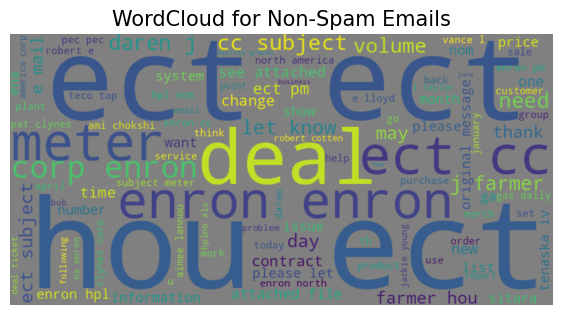

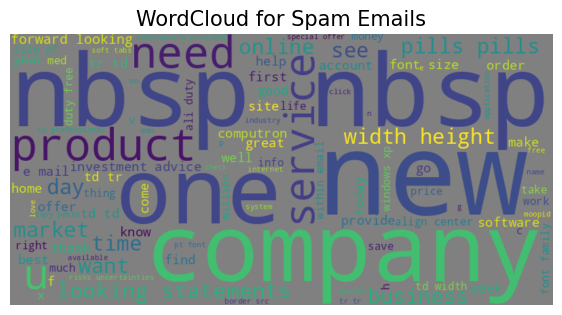

In [103]:
def plot_word_cloud(data, typ):
    email_corpus = " ".join(data['text'])
    wc = WordCloud(background_color='grey', max_words=100, width=800, height=400).generate(email_corpus)
    plt.figure(figsize=(7, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'WordCloud for {typ} Emails', fontsize=15)
    plt.axis('off')
    plt.show()

plot_word_cloud(bal_data[bal_data['label'] == 'ham'], typ='Non-Spam')
plot_word_cloud(bal_data[bal_data['label'] == 'spam'], typ='Spam')

In [104]:
train_X, test_X, train_Y, test_Y = train_test_split(bal_data['text'], bal_data['label'], test_size = 0.2, random_state= 42)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_X)

train_sequences = tokenizer.texts_to_sequences(train_X)
test_sequences = tokenizer.texts_to_sequences(test_X)

train_sequences = pad_sequences(train_sequences, maxlen = 100, padding = 'post', truncating = 'post')
test_sequences = pad_sequences(test_sequences, maxlen = 100, padding = 'post', truncating = 'post')

train_Y = (train_Y == 'spam').astype(int)
test_Y = (test_Y == 'spam').astype(int)

In [105]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(100,)),
    tf.keras.layers.Embedding(input_dim = len(tokenizer.word_index) + 1, output_dim = 32),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32, activation = 'relu'),
    tf.keras.layers.Dense(1, activation = 'sigmoid')
])

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer = 'adam',
    metrics = ['accuracy']
)

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 100, 32)        │     1,274,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,278,625 (4.88 MB)

 Trainable params: 1,278,625 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

In [106]:
es = EarlyStopping(patience = 3, monitor = 'val_accuracy', restore_best_weights = True)
lr = ReduceLROnPlateau(patience = 2, monitor = 'val_loss', factor = 0.5, verbose=0)

final = model.fit(
    train_sequences,
    train_Y,
    validation_data = (test_sequences, test_Y),
    epochs = 20,
    batch_size = 32,
    callbacks=[es,lr]
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.6802 - loss: 0.5971 - val_accuracy: 0.9233 - val_loss: 0.2776 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9487 - loss: 0.2002 - val_accuracy: 0.9517 - val_loss: 0.1908 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9650 - loss: 0.1433 - val_accuracy: 0.9583 - val_loss: 0.1823 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.9746 - loss: 0.1139 - val_accuracy: 0.9550 - val_loss: 0.1961 - learning_rate: 0.0010
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9825 - loss: 0.0831 - val_accuracy: 0.9533 - val_loss: 0.2225 - learning_rate: 0.0010
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9821 - loss: 0.0816 - val_accuracy: 0.9583 - val_loss: 0.1850 - learning_rate: 5.0000e-04


In [107]:
test_loss, test_accuracy = model.evaluate(test_sequences, test_Y)
print('Test loss:', test_loss)
print('Test accuracy:', test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9583 - loss: 0.1823
Test loss: 0.18226754665374756
Test accuracy: 0.9583333134651184


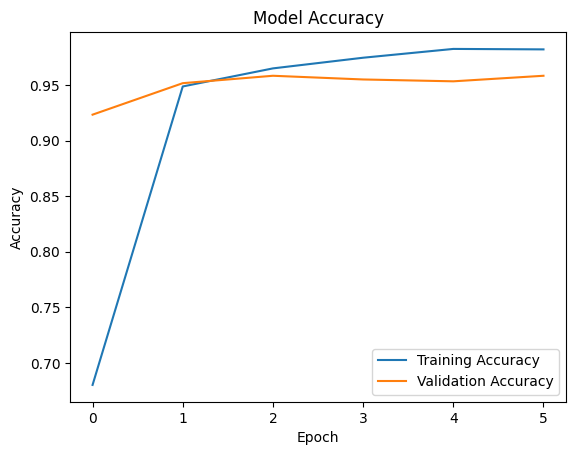

In [108]:
plt.plot(final.history['accuracy'], label='Training Accuracy')
plt.plot(final.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()